DATA A
Jorge Angon & Priyanshu Rathor

https://www.kaggle.com/datasets/grandmaster07/student-exam-score-dataset-analysis/data


In [ ]:
import numpy as nm
import matplotlib.pyplot as plt
import pandas as pd

# Read the csv file
df = pd.read_csv('student_exam_scores.csv')
df

,student_id,hours_studied,sleep_hours,attendance_percent,previous_scores,exam_score
0,S001,8.0,8.8,72.1,45,30.2
1,S002,1.3,8.6,60.7,55,25.0
2,S003,4.0,8.2,73.7,86,35.8
3,S004,3.5,4.8,95.1,66,34.0
4,S005,9.1,6.4,89.8,71,40.3
...,...,...,...,...,...,...
195,S196,10.5,5.4,94.0,87,42.7
196,S197,7.1,6.1,85.1,92,40.4
197,S198,1.6,6.9,63.8,76,28.2
198,S199,12.0,7.3,50.5,58,42.0


In [ ]:
# Check the data types
df.dtypes

,0
student_id,object
hours_studied,float64
sleep_hours,float64
attendance_percent,float64
previous_scores,int64
exam_score,float64


In [ ]:
# Split the dataset into x and y
# x is the input column
# y is the answer column
x = df[['hours_studied']].values
y = df['exam_score'].values

In [ ]:
# Split the data into training data and testing data
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.25, random_state=0
)

In [ ]:
# Train the linear regression model
from sklearn.linear_model import LinearRegression

regressor = LinearRegression()
regressor.fit(x_train, y_train)

LinearRegression()

In [ ]:
# Make predictions using the test data
y_pred = regressor.predict(x_test)
y_pred

array([39.62224901, 41.83400814, 33.14495441, 42.46593932, 32.98697162,
       42.62392212, 37.25250708, 34.88276516, 26.03572863, 33.14495441,
       36.6205759 , 31.24916087, 38.20040385, 27.61555658, 35.35671354,
       27.1416082 , 42.46593932, 30.93319528, 36.30461031, 36.93654149,
       27.29959099, 29.19538453, 29.66933292, 29.35336733, 42.78190491,
       34.72478236, 33.6189028 , 31.40714367, 39.14830062, 26.9836254 ,
       29.35336733, 36.14662752, 42.78190491, 30.14328131, 31.40714367,
       33.30293721, 39.9382146 , 38.35838665, 41.20207696, 27.45757379,
       26.9836254 , 29.51135013, 27.1416082 , 28.72143615, 29.35336733,
       37.41048988, 32.82898882, 32.51302323, 36.14662752, 40.72812858])

In [ ]:
# Compare the real answers and predicted answers
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results

,Actual,Predicted
0,35.6,39.622249
1,45.3,41.834008
2,39.2,33.144954
3,39.9,42.465939
4,31.0,32.986972
5,44.1,42.623922
6,35.7,37.252507
7,45.8,34.882765
8,31.2,26.035729
9,27.7,33.144954


In [ ]:
# Check how well the model did
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"Mean Squared Error: {mse}")
print(f"R-squared: {r2}")

Mean Absolute Error: 3.6306233141270843
Mean Squared Error: 19.85611175348557
R-squared: 0.6261110451198431


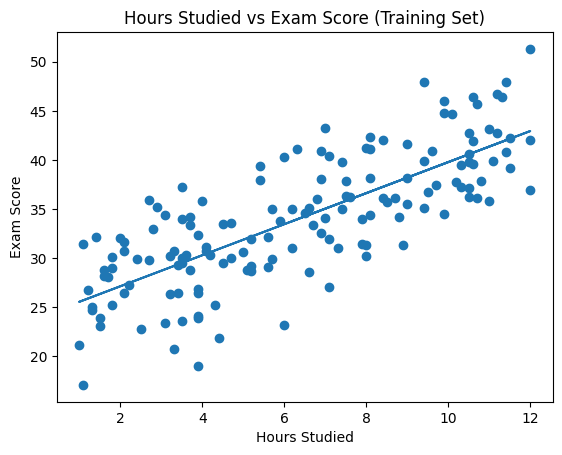

In [ ]:
# Plot the training data and the regression line
plt.scatter(x_train, y_train)
plt.plot(x_train, regressor.predict(x_train))
plt.title('Hours Studied vs Exam Score (Training Set)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

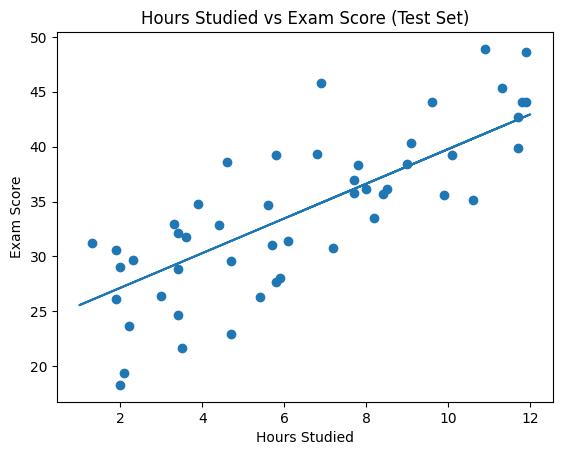

In [ ]:
# Plot the testing data and the regression line
plt.scatter(x_test, y_test)
plt.plot(x_train, regressor.predict(x_train))
plt.title('Hours Studied vs Exam Score (Test Set)')
plt.xlabel('Hours Studied')
plt.ylabel('Exam Score')
plt.show()

In [ ]:
# Lets us enter our own data
while True:
    try:
        hours_studied = float(input("Enter hours studied: "))

        new_data_point = nm.array([[hours_studied]])
        prediction = regressor.predict(new_data_point)

        print(f"Predicted Exam Score: {prediction[0]}")

        break

    except ValueError:
        print("Invalid input. Please enter a valid number.")
    except Exception as e:
        print(f"An error occurred: {e}")

Enter hours studied: 10
Predicted Exam Score: 39.780231804903245


So for this data, we used linear regression to predict a students score based on the hours that they studied. The model looked at past student data and learned the general apptern between the study time and and exam performance. When we tested the model it showed a moderate fit with a r square value of 0.64 which means hours studied did have an impact on exam scores but not soley the reason why. The average prediction error was about 3.63 points so the model was usually in the right range even if it was not exact every single time. We also used graphs to show the data points and the best fit line which show that this model gives a reasonable edtiamte of a students exam score from the number of hour they studied.